# Feature Engineering — Obesity Dataset

**Source:** [UCI Repository #544](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)  
**Reference:** Palechor & de la Hoz Manotas (2019). *Data in Brief*, doi:10.1016/j.dib.2019.104344

---

## Dataset Variable Reference

| Column | Role | Original Type | Survey Question / Meaning | Scale / Values |
|--------|------|---------------|---------------------------|----------------|
| `Gender` | Feature | Categorical | Biological sex | Female / Male |
| `Age` | Feature | Continuous | Age in years | 14 – 61 |
| `Height` | Feature | Continuous | Height in metres | 1.45 – 1.98 m |
| `Weight` | Feature | Continuous | Weight in kg | 39 – 173 kg |
| `family_history_with_overweight` | Feature | Binary | Has a family member suffered from overweight? | yes / no |
| `FAVC` | Feature | Binary | Do you eat high caloric food frequently? | yes / no |
| `FCVC` | Feature | **Ordinal Survey → SMOTE-continuous** | Do you eat vegetables in your meals? | 1=Never · 2=Sometimes · 3=Always |
| `NCP` | Feature | **Ordinal Survey → SMOTE-continuous** | How many main meals per day? | 1 · 2 · 3 · 4+ |
| `CAEC` | Feature | Categorical (ordered) | Do you eat food between meals? | no · Sometimes · Frequently · Always |
| `SMOKE` | Feature | Binary | Do you smoke? | yes / no |
| `CH2O` | Feature | **Ordinal Survey → SMOTE-continuous** | How much water do you drink daily? | 1=<1 L · 2=1–2 L · 3=>2 L |
| `SCC` | Feature | Binary | Do you monitor calorie intake daily? | yes / no |
| `FAF` | Feature | **Ordinal Survey → SMOTE-continuous** | Physical activity frequency (days/week)? | 0=None · 1=1–2 d · 2=2–4 d · 3=4–5 d |
| `TUE` | Feature | **Ordinal Survey → SMOTE-continuous** | Daily technology device use time? | 0=0–2 h · 1=3–5 h · 2=>5 h |
| `CALC` | Feature | Categorical (ordered) | How often do you drink alcohol? | no · Sometimes · Frequently · Always |
| `MTRANS` | Feature | Categorical (nominal) | Transportation mode usually used | Automobile · Motorbike · Bike · Public_Transportation · Walking |
| `NObeyesdad` | **Target** | Categorical (ordered) | Estimated obesity level | Insufficient_Weight · Normal_Weight · Overweight_Level_I · Overweight_Level_II · Obesity_Type_I · Obesity_Type_II · Obesity_Type_III |

> **Important note on SMOTE columns:** `FCVC`, `NCP`, `CH2O`, `FAF`, and `TUE` were collected as discrete survey integers but the synthetic portion of the dataset was generated via SMOTE interpolation, producing continuous values between the original integers. Both the continuous value and the rounded-integer interpretation carry valid information.

---

## Techniques Covered

| # | Section |
|---|---------|
| 1 | Setup & Data Loading |
| 2 | Exploratory Overview |
| 3 | Helper Utilities |
| 4 | Ordinal-Numeric Recovery (SMOTE columns) |
| 5 | Domain-Driven Feature Construction |
| 6 | Binary Encoding |
| 7 | Ordinal Encoding |
| 8 | One-Hot Encoding |
| 9 | Frequency / Count Encoding |
| 10 | Target Encoding (K-Fold, leak-free) |
| 11 | Aggregation Features |
| 12 | Interaction & Ratio Features |
| 13 | Polynomial Features |
| 14 | Binning / Discretisation |
| 15 | Log & Power Transformations |
| 16 | Feature Scaling |
| 17 | Summary & Save |

---
## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import (
    PolynomialFeatures,
    MinMaxScaler, StandardScaler, RobustScaler,
    PowerTransformer
)
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
np.random.seed(SEED)

RAW_PATH = 'ObesityDataSet_raw_and_data_sinthetic.csv'
df_raw   = pd.read_csv(RAW_PATH)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0000,1.6200,64.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,0.0000,1.0000,no,Public_Transportation,Normal_Weight
1,Female,21.0000,1.5200,56.0000,yes,no,3.0000,3.0000,Sometimes,yes,3.0000,yes,3.0000,0.0000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0000,1.8000,77.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,2.0000,1.0000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0000,1.8000,87.0000,no,no,3.0000,3.0000,Sometimes,no,2.0000,no,2.0000,0.0000,Frequently,Walking,Overweight_Level_I
4,Male,22.0000,1.7800,89.8000,no,no,2.0000,1.0000,Sometimes,no,2.0000,no,0.0000,0.0000,Sometimes,Public_Transportation,Overweight_Level_II


### Column type registry

Centralised lists used throughout the notebook so we never hard-code column names in multiple places.

In [ ]:
TARGET_COL  = 'NObeyesdad'

# True continuous (real-valued measurements)
CONT_COLS   = ['Age', 'Height', 'Weight']

# Originally ordinal survey integers, SMOTE-interpolated to continuous
SMOTE_ORD   = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Binary yes/no
BIN_COLS    = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

# Ordered categorical
ORD_CAT     = ['CAEC', 'CALC']          # no < Sometimes < Frequently < Always

# Nominal categorical
NOM_CAT     = ['Gender', 'MTRANS']

# Ordered target
TARGET_ORDER = {
    'Insufficient_Weight': 0,
    'Normal_Weight'      : 1,
    'Overweight_Level_I' : 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I'     : 4,
    'Obesity_Type_II'    : 5,
    'Obesity_Type_III'   : 6,
}

FREQ_ORDER  = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

# SMOTE column metadata: (min, max, label map)
SMOTE_META  = {
    'FCVC': {1: 'Never', 2: 'Sometimes', 3: 'Always'},
    'NCP' : {1: '1_meal', 2: '2_meals', 3: '3_meals', 4: '4+_meals'},
    'CH2O': {1: 'LessThan1L', 2: '1to2L', 3: 'MoreThan2L'},
    'FAF' : {0: 'No_activity', 1: '1to2_days', 2: '2to4_days', 3: '4to5_days'},
    'TUE' : {0: '0to2h', 1: '3to5h', 2: 'MoreThan5h'},
}

print('Column registry set.')

Column registry set.


---
## 2. Exploratory Overview

In [ ]:
print('=== dtypes ===')
print(df_raw.dtypes)
print('\n=== null counts ===')
print(df_raw.isnull().sum())
print('\n=== numerical describe ===')
df_raw.describe()

=== dtypes ===
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

=== null counts ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.0000,2111.0000,2111.0000,2111.0000,2111.0000,2111.0000,2111.0000,2111.0000
mean,24.3126,1.7017,86.5861,2.4190,2.6856,2.0080,1.0103,0.6579
std,6.3460,0.0933,26.1912,0.5339,0.7780,0.6130,0.8506,0.6089
min,14.0000,1.4500,39.0000,1.0000,1.0000,1.0000,0.0000,0.0000
25%,19.9472,1.6300,65.4733,2.0000,2.6587,1.5848,0.1245,0.0000
50%,22.7779,1.7005,83.0000,2.3855,3.0000,2.0000,1.0000,0.6253
75%,26.0000,1.7685,107.4307,3.0000,3.0000,2.4774,1.6667,1.0000
max,61.0000,1.9800,173.0000,3.0000,4.0000,3.0000,3.0000,2.0000


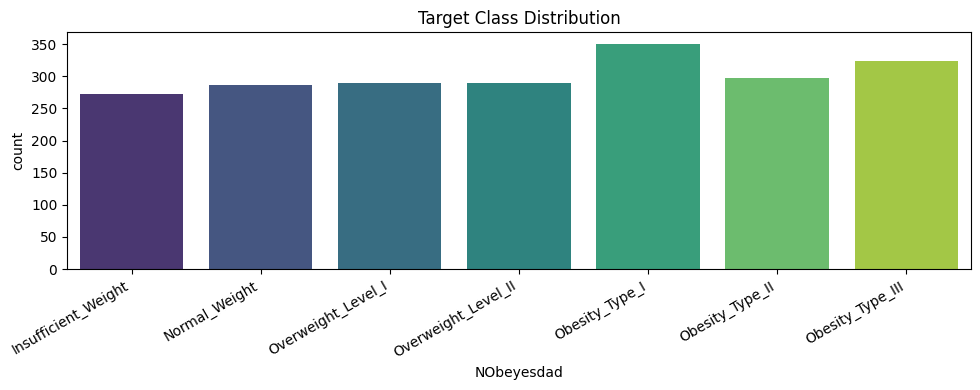

In [ ]:
# ── Target distribution ────────────────────────────────────────────────────────
target_order = list(TARGET_ORDER.keys())
plt.figure(figsize=(10, 4))
ax = sns.countplot(data=df_raw, x=TARGET_COL, order=target_order, palette='viridis')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.title('Target Class Distribution')
plt.tight_layout()
plt.show()

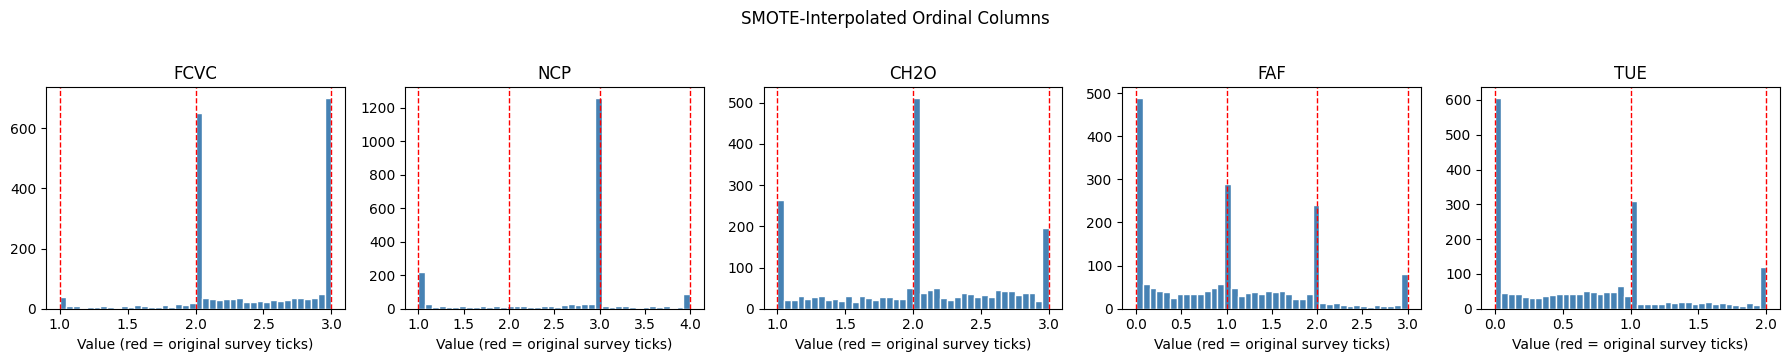

In [ ]:
# ── SMOTE column distributions — verify continuous interpolation ───────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, SMOTE_ORD):
    ax.hist(df_raw[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    meta = SMOTE_META[col]
    for k, v in meta.items():
        ax.axvline(k, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Value (red = original survey ticks)')
plt.suptitle('SMOTE-Interpolated Ordinal Columns', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Helper Utilities

Reusable functions used throughout the notebook.

In [ ]:
def show_new_columns(df_before: pd.DataFrame, df_after: pd.DataFrame) -> None:
    """Print a preview of columns added to df_after that were not in df_before."""
    new_cols = [c for c in df_after.columns if c not in df_before.columns]
    print(f'{len(new_cols)} new column(s): {new_cols}')
    if new_cols:
        display(df_after[new_cols].head(3))


def plot_distributions(df: pd.DataFrame, cols: list, ncols: int = 3) -> None:
    """Plot histograms for a list of numeric columns."""
    nrows = -(-len(cols) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='white', color='steelblue')
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


print('Helpers loaded.')

Helpers loaded.


---
## 4. Ordinal-Numeric Recovery (SMOTE Columns)

Because `FCVC`, `NCP`, `CH2O`, `FAF`, and `TUE` were originally **integer survey answers** (e.g. 1 = Never, 2 = Sometimes, 3 = Always) and the synthetic portion was generated by SMOTE interpolation, we:

1. **Round** each column to the nearest integer to recover the original survey category.
2. **Map** the integer to a human-readable label (useful for ordinal encoding later).
3. Keep the **raw continuous value** alongside — tree models can exploit the continuous signal directly.

In [ ]:
def recover_smote_ordinals(
    df: pd.DataFrame,
    smote_meta: dict
) -> pd.DataFrame:
    """
    For each SMOTE-interpolated ordinal column:
      - Add a `<col>_int`   column: value rounded to the nearest valid integer.
      - Add a `<col>_label` column: human-readable survey category for that integer.

    Parameters
    ----------
    df         : input dataframe
    smote_meta : {col: {int_val: label_str, ...}, ...}  — from SMOTE_META registry
    """
    out = df.copy()
    for col, label_map in smote_meta.items():
        valid_ints = sorted(label_map.keys())
        lo, hi     = min(valid_ints), max(valid_ints)

        # Round and clip to valid integer range
        rounded = out[col].round().clip(lo, hi).astype(int)
        out[f'{col}_int']   = rounded
        out[f'{col}_label'] = rounded.map(label_map)
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
df     = df_raw.copy()
before = df.copy()
df     = recover_smote_ordinals(df, SMOTE_META)
show_new_columns(before, df)

print('\nFCVC_label distribution:')
print(df['FCVC_label'].value_counts())
print('\nFAF_label distribution:')
print(df['FAF_label'].value_counts())

10 new column(s): ['FCVC_int', 'FCVC_label', 'NCP_int', 'NCP_label', 'CH2O_int', 'CH2O_label', 'FAF_int', 'FAF_label', 'TUE_int', 'TUE_label']


,FCVC_int,FCVC_label,NCP_int,NCP_label,CH2O_int,CH2O_label,FAF_int,FAF_label,TUE_int,TUE_label
0,2,Sometimes,3,3_meals,2,1to2L,0,No_activity,1,3to5h
1,3,Always,3,3_meals,3,MoreThan2L,3,4to5_days,0,0to2h
2,2,Sometimes,3,3_meals,2,1to2L,2,2to4_days,1,3to5h



FCVC_label distribution:
FCVC_label
Sometimes    1013
Always        996
Never         102
Name: count, dtype: int64

FAF_label distribution:
FAF_label
1to2_days      776
No_activity    720
2to4_days      496
4to5_days      119
Name: count, dtype: int64


---
## 5. Domain-Driven Feature Construction

Physically and medically meaningful features derived from the variable definitions.

| Feature | Formula / Logic | Rationale |
|---------|----------------|-----------|
| `BMI` | Weight / Height² | Standard body mass index |
| `BMI_category` | WHO cutpoints | Clinical weight classification |
| `weight_height_ratio` | Weight / Height | Simpler body-size proxy |
| `health_score` | FAF_int + CH2O_int + FCVC_int | Higher = more active, hydrated, veggie-eating |
| `risk_score` | FAVC_bin + SMOKE_bin + CAEC_ord + CALC_ord | Higher = more dietary/lifestyle risk factors |
| `sedentary_score` | TUE_int + mtrans_passivity | Higher = more sedentary lifestyle |
| `caloric_balance_proxy` | health_score − risk_score | Positive = net healthy behaviours |
| `activity_to_sedentary` | FAF_int / (TUE_int + 1) | Ratio of active to screen time |
| `hydration_per_meal` | CH2O_int / NCP_int | Water consumption relative to meal count |
| `age_group` | Binned Age | Categorical age band |

In [ ]:
def build_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct physically and medically meaningful composite features.
    Requires that recover_smote_ordinals() has already been run so that
    the *_int columns are available.
    """
    out = df.copy()

    # ── Body composition ──────────────────────────────────────────────────
    out['BMI']               = out['Weight'] / (out['Height'] ** 2)
    out['weight_height_ratio'] = out['Weight'] / out['Height']

    bmi_bins   = [0, 18.5, 25, 30, 35, 40, np.inf]
    bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese_I', 'Obese_II', 'Obese_III']
    out['BMI_category'] = pd.cut(out['BMI'], bins=bmi_bins,
                                  labels=bmi_labels, include_lowest=True)

    # ── Age group ─────────────────────────────────────────────────────────
    age_bins   = [0, 18, 25, 35, 50, np.inf]
    age_labels = ['<18', '18-25', '26-35', '36-50', '50+']
    out['age_group'] = pd.cut(out['Age'], bins=age_bins,
                               labels=age_labels, include_lowest=True)

    # ── Composite scores  (use recovered integer values for interpretability)
    # Healthy lifestyle — FAF scale 0–3, CH2O scale 1–3, FCVC scale 1–3 → max = 9
    out['health_score'] = out['FAF_int'] + out['CH2O_int'] + out['FCVC_int']

    # Risk factors — binary flags + ordered alcohol/snacking frequency (0–3 each)
    bin_map   = {'yes': 1, 'no': 0}
    caec_ord  = out['CAEC'].map(FREQ_ORDER)
    calc_ord  = out['CALC'].map(FREQ_ORDER)
    out['risk_score'] = (
        out['FAVC'].map(bin_map)
        + out['SMOKE'].map(bin_map)
        + caec_ord
        + calc_ord
    )

    # Sedentary lifestyle — TUE scale 0–2 + transportation passivity (0–3)
    mtrans_passivity = {
        'Walking': 0, 'Bike': 0,
        'Public_Transportation': 1,
        'Motorbike': 2, 'Automobile': 3
    }
    out['sedentary_score'] = out['TUE_int'] + out['MTRANS'].map(mtrans_passivity)

    # Net lifestyle balance — positive means more healthy than risky
    out['caloric_balance_proxy'] = out['health_score'] - out['risk_score']

    # Activity-to-screen ratio — +1 prevents div-by-zero when TUE=0
    out['activity_to_sedentary'] = out['FAF_int'] / (out['TUE_int'] + 1)

    # Water intake relative to number of meals (hydration per eating occasion)
    out['hydration_per_meal'] = out['CH2O_int'] / out['NCP_int'].replace(0, np.nan)

    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()
df     = build_domain_features(df)
show_new_columns(before, df)

10 new column(s): ['BMI', 'weight_height_ratio', 'BMI_category', 'age_group', 'health_score', 'risk_score', 'sedentary_score', 'caloric_balance_proxy', 'activity_to_sedentary', 'hydration_per_meal']


,BMI,weight_height_ratio,BMI_category,age_group,health_score,risk_score,sedentary_score,caloric_balance_proxy,activity_to_sedentary,hydration_per_meal
0,24.3865,39.5062,Normal,18-25,4,1,2,3,0.0000,0.6667
1,24.2382,36.8421,Normal,18-25,9,3,1,6,3.0000,1.0000
2,23.7654,42.7778,Normal,18-25,6,3,2,3,1.0000,0.6667


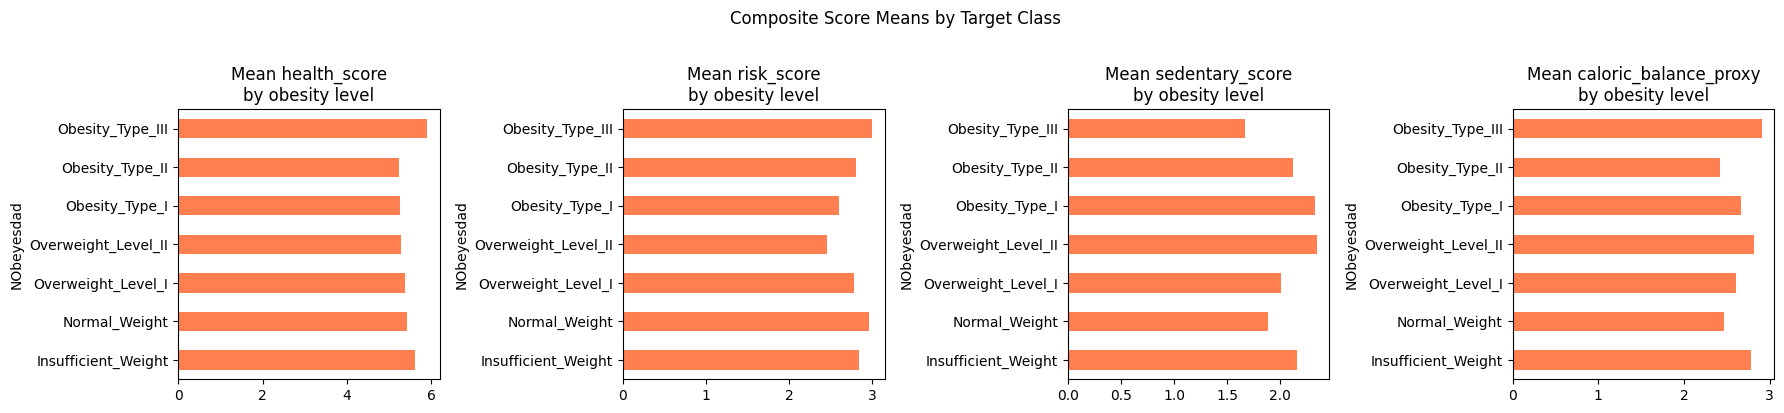

In [ ]:
# ── Visualise composite scores vs target ──────────────────────────────────────
scores = ['health_score', 'risk_score', 'sedentary_score', 'caloric_balance_proxy']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, scores):
    df.groupby(TARGET_COL)[col].mean().reindex(TARGET_ORDER.keys()).plot(
        kind='barh', ax=ax, color='coral')
    ax.set_title(f'Mean {col}\nby obesity level')
plt.suptitle('Composite Score Means by Target Class', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Binary Encoding

Map `yes`/`no` columns to `1`/`0`.

In [ ]:
def apply_binary_encoding(
    df: pd.DataFrame,
    columns: list,
    true_val: str = 'yes'
) -> pd.DataFrame:
    """
    Encode binary yes/no columns as integer 1/0.

    Parameters
    ----------
    columns  : list of binary columns to encode
    true_val : string value that maps to 1
    """
    out = df.copy()
    for col in columns:
        out[f'{col}_bin'] = (out[col].str.lower() == true_val.lower()).astype(int)
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()
df     = apply_binary_encoding(df, BIN_COLS)
show_new_columns(before, df)

4 new column(s): ['family_history_with_overweight_bin', 'FAVC_bin', 'SMOKE_bin', 'SCC_bin']


,family_history_with_overweight_bin,FAVC_bin,SMOKE_bin,SCC_bin
0,1,0,0,0
1,1,0,1,1
2,1,0,0,0


---
## 7. Ordinal Encoding

Encode **ordered** categories with integer ranks that preserve the natural order.

- `CAEC` / `CALC`: `no=0`, `Sometimes=1`, `Frequently=2`, `Always=3`
- `FCVC_label`, `CH2O_label`, `FAF_label`, `TUE_label`: derived from recovered integer labels
- `NObeyesdad`: `Insufficient_Weight=0` → `Obesity_Type_III=6`

In [ ]:
def apply_ordinal_encoding(
    df: pd.DataFrame,
    col_order_map: dict
) -> pd.DataFrame:
    """
    Ordinal-encode columns using explicit category ordering.

    Parameters
    ----------
    col_order_map : {column_name: [ordered_category_list]}
                    First item in the list receives rank 0.
    """
    out = df.copy()
    for col, order in col_order_map.items():
        mapping = {val: rank for rank, val in enumerate(order)}
        out[f'{col}_ordinal'] = out[col].map(mapping)
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
freq_order_list  = ['no', 'Sometimes', 'Frequently', 'Always']
target_ord_list  = list(TARGET_ORDER.keys())

# SMOTE label orderings (ascending severity/amount)
fcvc_order  = ['Never', 'Sometimes', 'Always']
ncp_order   = ['1_meal', '2_meals', '3_meals', '4+_meals']
ch2o_order  = ['LessThan1L', '1to2L', 'MoreThan2L']
faf_order   = ['No_activity', '1to2_days', '2to4_days', '4to5_days']
tue_order   = ['0to2h', '3to5h', 'MoreThan5h']

ordinal_specs = {
    'CAEC'       : freq_order_list,
    'CALC'       : freq_order_list,
    TARGET_COL   : target_ord_list,
    'FCVC_label' : fcvc_order,
    'NCP_label'  : ncp_order,
    'CH2O_label' : ch2o_order,
    'FAF_label'  : faf_order,
    'TUE_label'  : tue_order,
}

before = df.copy()
df     = apply_ordinal_encoding(df, ordinal_specs)
show_new_columns(before, df)
print('\nCAEC ordinal mapping:')
print(df[['CAEC', 'CAEC_ordinal']].drop_duplicates().sort_values('CAEC_ordinal'))

8 new column(s): ['CAEC_ordinal', 'CALC_ordinal', 'NObeyesdad_ordinal', 'FCVC_label_ordinal', 'NCP_label_ordinal', 'CH2O_label_ordinal', 'FAF_label_ordinal', 'TUE_label_ordinal']


,CAEC_ordinal,CALC_ordinal,NObeyesdad_ordinal,FCVC_label_ordinal,NCP_label_ordinal,CH2O_label_ordinal,FAF_label_ordinal,TUE_label_ordinal
0,1,0,1,1,2,1,0,1
1,1,1,1,2,2,2,3,0
2,1,2,1,1,2,1,2,1



CAEC ordinal mapping:
          CAEC  CAEC_ordinal
44          no             0
0    Sometimes             1
10  Frequently             2
15      Always             3


---
## 8. One-Hot Encoding

Create a binary dummy column for each distinct category value.  
Applied to **nominal** variables: `Gender` and `MTRANS` (no natural order).

In [ ]:
def apply_ohe(
    df: pd.DataFrame,
    columns: list,
    drop_first: bool = True
) -> pd.DataFrame:
    """
    One-Hot Encode the specified categorical columns.

    Parameters
    ----------
    columns    : nominal categorical columns to encode
    drop_first : drop the first dummy to avoid perfect multicollinearity
    """
    out    = df.copy()
    dummies = pd.get_dummies(
        out[columns],
        columns=columns,
        drop_first=drop_first,
        dtype=int
    )
    return pd.concat([out, dummies], axis=1)


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()
df     = apply_ohe(df, columns=NOM_CAT)
show_new_columns(before, df)

5 new column(s): ['Gender_Male', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,0,0,1,0
1,0,0,0,1,0
2,1,0,0,1,0


---
## 9. Frequency / Count Encoding

Replace each category with its **relative frequency** in the dataset.  
Captures how common a group is — useful when frequency itself is a signal  
(e.g., `Public_Transportation` being the most common MTRANS).

In [ ]:
def apply_frequency_encoding(
    df: pd.DataFrame,
    columns: list,
    normalize: bool = True
) -> pd.DataFrame:
    """
    Encode categorical columns by their occurrence frequency.

    Parameters
    ----------
    columns   : categorical columns to encode
    normalize : True → relative frequency (0–1); False → raw count
    """
    out    = df.copy()
    suffix = 'freq' if normalize else 'count'
    for col in columns:
        freq_map        = out[col].value_counts(normalize=normalize)
        out[f'{col}_{suffix}'] = out[col].map(freq_map)
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()
df     = apply_frequency_encoding(df, columns=['MTRANS', 'CAEC', 'CALC', 'Gender'])
show_new_columns(before, df)

print('\nMTRANS frequency values:')
print(df[['MTRANS', 'MTRANS_freq']].drop_duplicates().sort_values('MTRANS_freq', ascending=False))

4 new column(s): ['MTRANS_freq', 'CAEC_freq', 'CALC_freq', 'Gender_freq']


,MTRANS_freq,CAEC_freq,CALC_freq,Gender_freq
0,0.7485,0.8361,0.3027,0.4941
1,0.7485,0.8361,0.6637,0.4941
2,0.7485,0.8361,0.0332,0.5059



MTRANS frequency values:
                   MTRANS  MTRANS_freq
0   Public_Transportation       0.7485
5              Automobile       0.2165
3                 Walking       0.0265
6               Motorbike       0.0052
73                   Bike       0.0033


---
## 10. Target Encoding (K-Fold, Leak-Free)

Replace each category with the **mean of the (ordinal) target** for that group.  

We use **K-Fold out-of-fold (OOF)** target encoding with additive smoothing to prevent data leakage:
- Each fold's validation rows are encoded using statistics computed only from the **training folds**.
- **Smoothing** pulls group means toward the global mean when a group has few observations.

$$\text{encoded}(g) = \frac{n_g \cdot \bar{y}_g + \lambda \cdot \bar{y}_{\text{global}}}{n_g + \lambda}$$

In [ ]:
def apply_target_encoding_kfold(
    df: pd.DataFrame,
    columns: list,
    target_col: str,
    target_order: dict,
    n_splits: int = 5,
    smoothing: float = 1.0,
    seed: int = SEED
) -> pd.DataFrame:
    """
    Out-of-fold K-Fold Target Encoding with additive smoothing.

    Parameters
    ----------
    df           : dataframe containing features and target
    columns      : categorical columns to encode
    target_col   : target column name (string or numeric)
    target_order : {category_string: integer_rank} used when target is categorical
    n_splits     : number of KFold splits (typically 5)
    smoothing    : lambda — higher value pulls more toward global mean
    """
    out = df.copy()

    if out[target_col].dtype == object or str(out[target_col].dtype) == 'category':
        numeric_target = out[target_col].map(target_order).astype(float)
    else:
        numeric_target = out[target_col].astype(float)

    global_mean = numeric_target.mean()
    kf          = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in columns:
        te_values = np.zeros(len(out), dtype=float)

        for train_idx, val_idx in kf.split(out):
            train_y   = numeric_target.iloc[train_idx]
            train_col = out[col].iloc[train_idx]

            stats = (
                pd.DataFrame({'cat': train_col, 'y': train_y})
                .groupby('cat')['y']
                .agg(['mean', 'count'])
            )
            stats['smoothed'] = (
                (stats['count'] * stats['mean'] + smoothing * global_mean)
                / (stats['count'] + smoothing)
            )

            val_cat = out[col].iloc[val_idx]
            te_values[val_idx] = (
                val_cat.map(stats['smoothed']).fillna(global_mean).values
            )

        out[f'{col}_target_enc'] = te_values

    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
# Encode all categorical columns — including recovered SMOTE labels
te_columns = ['Gender', 'MTRANS', 'CAEC', 'CALC',
              'FCVC_label', 'CH2O_label', 'FAF_label', 'TUE_label', 'NCP_label']

before = df.copy()
df     = apply_target_encoding_kfold(
    df, columns=te_columns,
    target_col=TARGET_COL, target_order=TARGET_ORDER
)
show_new_columns(before, df)

9 new column(s): ['Gender_target_enc', 'MTRANS_target_enc', 'CAEC_target_enc', 'CALC_target_enc', 'FCVC_label_target_enc', 'CH2O_label_target_enc', 'FAF_label_target_enc', 'TUE_label_target_enc', 'NCP_label_target_enc']


,Gender_target_enc,MTRANS_target_enc,CAEC_target_enc,CALC_target_enc,FCVC_label_target_enc,CH2O_label_target_enc,FAF_label_target_enc,TUE_label_target_enc,NCP_label_target_enc
0,3.2033,3.2220,3.5431,2.5326,2.7757,2.9706,3.5469,3.3193,3.4385
1,3.1043,3.1668,3.4573,3.3565,3.4722,3.5874,2.0205,3.1052,3.3768
2,3.0610,3.1864,3.4849,2.5475,2.8134,2.9728,2.7745,3.2684,3.4240


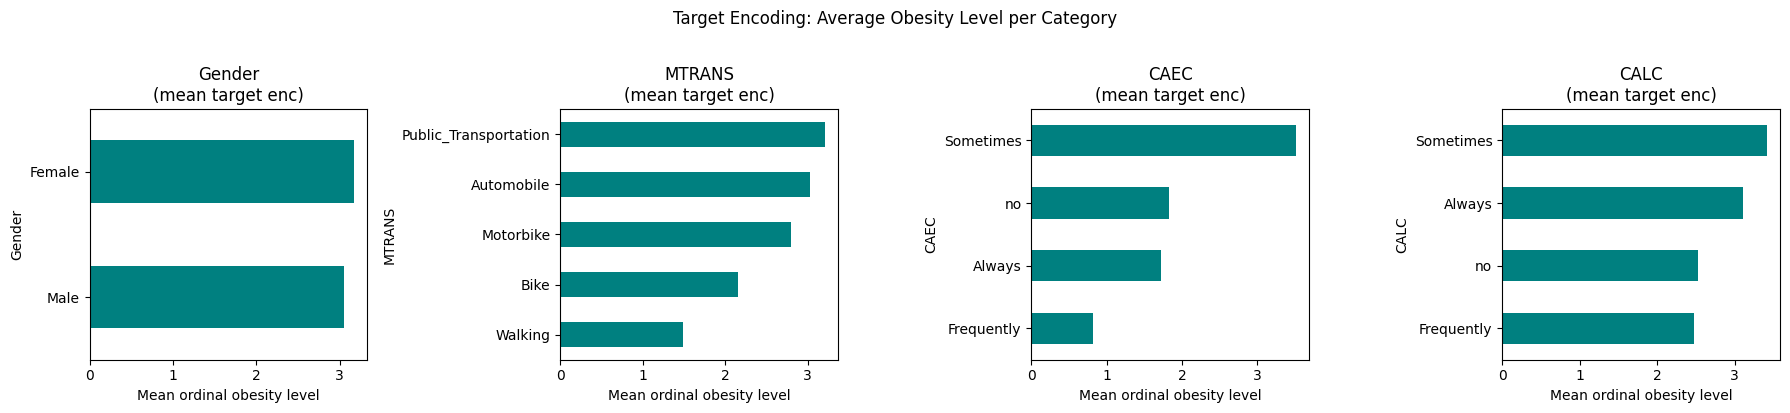

In [ ]:
# ── Visualise: mean target encoding by category ───────────────────────────────
vis_cols = ['Gender', 'MTRANS', 'CAEC', 'CALC']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, vis_cols):
    means = df.groupby(col)[f'{col}_target_enc'].mean().sort_values()
    means.plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{col}\n(mean target enc)')
    ax.set_xlabel('Mean ordinal obesity level')
plt.suptitle('Target Encoding: Average Obesity Level per Category', y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Aggregation Features

Compute group-level statistics (mean, std, min, max) of numeric columns grouped by a categorical variable, then merge them back onto each row.  
This gives every observation a **within-group context** that individual values alone cannot express.

E.g., a BMI of 28 means something different for a 20-year-old vs. a 50-year-old — `age_group_BMI_mean` captures the group baseline.

In [ ]:
def build_aggregation_features(
    df: pd.DataFrame,
    group_cols: list,
    agg_cols: list,
    agg_funcs: list = None
) -> pd.DataFrame:
    """
    Build group aggregation features via every (group_col × agg_col × agg_func)
    combination, then merge results back onto the dataframe.

    Parameters
    ----------
    group_cols : columns to group by  (e.g. ['Gender', 'age_group'])
    agg_cols   : numeric columns to aggregate  (e.g. ['BMI', 'FAF_int'])
    agg_funcs  : functions to apply; defaults to ['mean', 'std', 'min', 'max']
    """
    if agg_funcs is None:
        agg_funcs = ['mean', 'std', 'min', 'max']

    out = df.copy()
    for grp_col in group_cols:
        for agg_col in agg_cols:
            grouped = out.groupby(grp_col)[agg_col].agg(agg_funcs)
            grouped.columns = [f'{grp_col}_{agg_col}_{fn}' for fn in agg_funcs]
            out = out.merge(grouped, on=grp_col, how='left')
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()
df = build_aggregation_features(
    df,
    group_cols=['Gender', 'age_group', 'MTRANS'],
    agg_cols=['BMI', 'FAF_int', 'Weight', 'CH2O_int', 'health_score'],
    agg_funcs=['mean', 'std', 'min', 'max']
)
show_new_columns(before, df)

60 new column(s): ['Gender_BMI_mean', 'Gender_BMI_std', 'Gender_BMI_min', 'Gender_BMI_max', 'Gender_FAF_int_mean', 'Gender_FAF_int_std', 'Gender_FAF_int_min', 'Gender_FAF_int_max', 'Gender_Weight_mean', 'Gender_Weight_std', 'Gender_Weight_min', 'Gender_Weight_max', 'Gender_CH2O_int_mean', 'Gender_CH2O_int_std', 'Gender_CH2O_int_min', 'Gender_CH2O_int_max', 'Gender_health_score_mean', 'Gender_health_score_std', 'Gender_health_score_min', 'Gender_health_score_max', 'age_group_BMI_mean', 'age_group_BMI_std', 'age_group_BMI_min', 'age_group_BMI_max', 'age_group_FAF_int_mean', 'age_group_FAF_int_std', 'age_group_FAF_int_min', 'age_group_FAF_int_max', 'age_group_Weight_mean', 'age_group_Weight_std', 'age_group_Weight_min', 'age_group_Weight_max', 'age_group_CH2O_int_mean', 'age_group_CH2O_int_std', 'age_group_CH2O_int_min', 'age_group_CH2O_int_max', 'age_group_health_score_mean', 'age_group_health_score_std', 'age_group_health_score_min', 'age_group_health_score_max', 'MTRANS_BMI_mean', 'MTR

,Gender_BMI_mean,Gender_BMI_std,Gender_BMI_min,Gender_BMI_max,Gender_FAF_int_mean,Gender_FAF_int_std,Gender_FAF_int_min,Gender_FAF_int_max,Gender_Weight_mean,Gender_Weight_std,Gender_Weight_min,Gender_Weight_max,Gender_CH2O_int_mean,Gender_CH2O_int_std,Gender_CH2O_int_min,Gender_CH2O_int_max,Gender_health_score_mean,Gender_health_score_std,Gender_health_score_min,Gender_health_score_max,age_group_BMI_mean,age_group_BMI_std,age_group_BMI_min,age_group_BMI_max,age_group_FAF_int_mean,age_group_FAF_int_std,age_group_FAF_int_min,age_group_FAF_int_max,age_group_Weight_mean,age_group_Weight_std,age_group_Weight_min,age_group_Weight_max,age_group_CH2O_int_mean,age_group_CH2O_int_std,age_group_CH2O_int_min,age_group_CH2O_int_max,age_group_health_score_mean,age_group_health_score_std,age_group_health_score_min,age_group_health_score_max,MTRANS_BMI_mean,MTRANS_BMI_std,MTRANS_BMI_min,MTRANS_BMI_max,MTRANS_FAF_int_mean,MTRANS_FAF_int_std,MTRANS_FAF_int_min,MTRANS_FAF_int_max,MTRANS_Weight_mean,MTRANS_Weight_std,MTRANS_Weight_min,MTRANS_Weight_max,MTRANS_CH2O_int_mean,MTRANS_CH2O_int_std,MTRANS_CH2O_int_min,MTRANS_CH2O_int_max,MTRANS_health_score_mean,MTRANS_health_score_std,MTRANS_health_score_min,MTRANS_health_score_max
0,30.1300,9.3994,12.9987,50.8118,0.8322,0.8869,0,3,82.3024,29.7239,39.0000,165.0573,1.9616,0.7281,1,3,5.3720,1.3728,2,9,28.6408,8.4218,15.7926,50.8118,1.1463,0.9000,0,3,83.7073,28.5590,39.0000,165.0573,2.0505,0.6845,1,3,5.6064,1.3912,2,9,30.1097,8.5111,12.9987,50.8118,0.9766,0.8645,0,3,87.4867,27.9233,39.0000,173.0000,2.0304,0.7022,1,3,5.4532,1.2963,2,9
1,30.1300,9.3994,12.9987,50.8118,0.8322,0.8869,0,3,82.3024,29.7239,39.0000,165.0573,1.9616,0.7281,1,3,5.3720,1.3728,2,9,28.6408,8.4218,15.7926,50.8118,1.1463,0.9000,0,3,83.7073,28.5590,39.0000,165.0573,2.0505,0.6845,1,3,5.6064,1.3912,2,9,30.1097,8.5111,12.9987,50.8118,0.9766,0.8645,0,3,87.4867,27.9233,39.0000,173.0000,2.0304,0.7022,1,3,5.4532,1.2963,2,9
2,29.2804,6.3469,13.2916,49.4724,1.1770,0.8710,0,3,90.7695,21.4070,45.0000,173.0000,2.0665,0.6438,1,3,5.5159,1.3269,2,9,28.6408,8.4218,15.7926,50.8118,1.1463,0.9000,0,3,83.7073,28.5590,39.0000,165.0573,2.0505,0.6845,1,3,5.6064,1.3912,2,9,30.1097,8.5111,12.9987,50.8118,0.9766,0.8645,0,3,87.4867,27.9233,39.0000,173.0000,2.0304,0.7022,1,3,5.4532,1.2963,2,9


In [ ]:
def build_group_deviation_features(
    df: pd.DataFrame,
    group_cols: list,
    value_cols: list
) -> pd.DataFrame:
    """
    For each (group_col, value_col) pair, compute how many standard deviations
    each row deviates from its group mean (within-group z-score).

    A negative value means the person is below their group's average;
    positive means above.
    """
    out = df.copy()
    for grp_col in group_cols:
        for val_col in value_cols:
            grp_mean = out.groupby(grp_col)[val_col].transform('mean')
            grp_std  = out.groupby(grp_col)[val_col].transform('std').replace(0, 1)
            out[f'{val_col}_dev_from_{grp_col}'] = (out[val_col] - grp_mean) / grp_std
    return out


before = df.copy()
df = build_group_deviation_features(
    df,
    group_cols=['Gender', 'age_group'],
    value_cols=['BMI', 'Weight', 'FAF_int', 'health_score']
)
show_new_columns(before, df)

8 new column(s): ['BMI_dev_from_Gender', 'Weight_dev_from_Gender', 'FAF_int_dev_from_Gender', 'health_score_dev_from_Gender', 'BMI_dev_from_age_group', 'Weight_dev_from_age_group', 'FAF_int_dev_from_age_group', 'health_score_dev_from_age_group']


,BMI_dev_from_Gender,Weight_dev_from_Gender,FAF_int_dev_from_Gender,health_score_dev_from_Gender,BMI_dev_from_age_group,Weight_dev_from_age_group,FAF_int_dev_from_age_group,health_score_dev_from_age_group
0,-0.6110,-0.6157,-0.9383,-0.9994,-0.5052,-0.6901,-1.2736,-1.1547
1,-0.6268,-0.8849,2.4442,2.6428,-0.5228,-0.9702,2.0597,2.4393
2,-0.8689,-0.6432,0.9449,0.3648,-0.5789,-0.2349,0.9486,0.2829


---
## 12. Interaction & Ratio Features

Explicit pairwise multiplications and ratios that encode meaningful relationships:

| Feature | Interpretation |
|---------|---------------|
| `FAF_int × health_score` | Active people with generally healthy habits |
| `BMI × risk_score` | High BMI combined with risky behaviours |
| `health_score / (risk_score + 1)` | Net healthy-to-risky ratio |
| `Weight × sedentary_score` | Heavy + sedentary interaction |
| `Age × BMI` | Age-weighted body composition |

In [ ]:
def build_interaction_features(
    df: pd.DataFrame,
    pairs: list,
    operations: list = None
) -> pd.DataFrame:
    """
    Generate interaction and ratio features for specified column pairs.

    Parameters
    ----------
    pairs      : list of (col_a, col_b) tuples
    operations : subset of ['product', 'ratio', 'diff', 'sum']
                 defaults to all four
    """
    if operations is None:
        operations = ['product', 'ratio', 'diff', 'sum']

    out = df.copy()
    for col_a, col_b in pairs:
        a, b = out[col_a], out[col_b]
        if 'product' in operations:
            out[f'{col_a}_x_{col_b}']     = a * b
        if 'ratio' in operations:
            out[f'{col_a}_div_{col_b}']   = a / b.replace(0, np.nan)
        if 'diff' in operations:
            out[f'{col_a}_minus_{col_b}'] = a - b
        if 'sum' in operations:
            out[f'{col_a}_plus_{col_b}']  = a + b
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
interaction_pairs = [
    ('FAF_int', 'TUE_int'),           # activity days vs screen hours
    ('BMI', 'Age'),                   # body composition × age
    ('health_score', 'risk_score'),   # healthy vs risky composites
    ('Weight', 'sedentary_score'),    # body weight × sedentary lifestyle
    ('NCP_int', 'FCVC_int'),          # meals × vegetable intake per meal
    ('CH2O_int', 'NCP_int'),          # water per meal opportunity
]

before = df.copy()
df     = build_interaction_features(df, interaction_pairs)
show_new_columns(before, df)

24 new column(s): ['FAF_int_x_TUE_int', 'FAF_int_div_TUE_int', 'FAF_int_minus_TUE_int', 'FAF_int_plus_TUE_int', 'BMI_x_Age', 'BMI_div_Age', 'BMI_minus_Age', 'BMI_plus_Age', 'health_score_x_risk_score', 'health_score_div_risk_score', 'health_score_minus_risk_score', 'health_score_plus_risk_score', 'Weight_x_sedentary_score', 'Weight_div_sedentary_score', 'Weight_minus_sedentary_score', 'Weight_plus_sedentary_score', 'NCP_int_x_FCVC_int', 'NCP_int_div_FCVC_int', 'NCP_int_minus_FCVC_int', 'NCP_int_plus_FCVC_int', 'CH2O_int_x_NCP_int', 'CH2O_int_div_NCP_int', 'CH2O_int_minus_NCP_int', 'CH2O_int_plus_NCP_int']


,FAF_int_x_TUE_int,FAF_int_div_TUE_int,FAF_int_minus_TUE_int,FAF_int_plus_TUE_int,BMI_x_Age,BMI_div_Age,BMI_minus_Age,BMI_plus_Age,health_score_x_risk_score,health_score_div_risk_score,health_score_minus_risk_score,health_score_plus_risk_score,Weight_x_sedentary_score,Weight_div_sedentary_score,Weight_minus_sedentary_score,Weight_plus_sedentary_score,NCP_int_x_FCVC_int,NCP_int_div_FCVC_int,NCP_int_minus_FCVC_int,NCP_int_plus_FCVC_int,CH2O_int_x_NCP_int,CH2O_int_div_NCP_int,CH2O_int_minus_NCP_int,CH2O_int_plus_NCP_int
0,0,0.0000,-1,1,512.1171,1.1613,3.3865,45.3865,4,4.0000,3,5,128.0000,32.0000,62.0000,66.0000,6,1.5000,1,5,6,0.6667,-1,5
1,0,NaN,3,3,509.0028,1.1542,3.2382,45.2382,27,3.0000,6,12,56.0000,56.0000,55.0000,57.0000,9,1.0000,0,6,9,1.0000,0,6
2,2,2.0000,1,3,546.6049,1.0333,0.7654,46.7654,18,2.0000,3,9,154.0000,38.5000,75.0000,79.0000,6,1.5000,1,5,6,0.6667,-1,5


---
## 13. Polynomial Features

Degree-2 polynomial expansion of key numeric features.  
Enables linear models to capture non-linear and joint effects.

In [ ]:
def build_polynomial_features(
    df: pd.DataFrame,
    columns: list,
    degree: int = 2,
    include_bias: bool = False,
    interaction_only: bool = False
) -> pd.DataFrame:
    """
    Add sklearn PolynomialFeatures for the specified columns.

    Parameters
    ----------
    columns          : numeric columns to expand
    degree           : polynomial degree (2 recommended to avoid explosion)
    include_bias     : whether to include the constant term
    interaction_only : True → only cross-terms, no x² terms
    """
    out  = df.copy()
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=include_bias,
        interaction_only=interaction_only
    )
    X_poly    = poly.fit_transform(out[columns].fillna(0))
    poly_cols = poly.get_feature_names_out(columns)

    # Keep only genuinely new terms (exclude the originals)
    new_terms = [c for c in poly_cols if c not in columns]
    new_idx   = [list(poly_cols).index(c) for c in new_terms]
    poly_df   = pd.DataFrame(
        X_poly[:, new_idx],
        columns=[f'poly_{c}' for c in new_terms],
        index=out.index
    )
    return pd.concat([out, poly_df], axis=1)


# ── Apply on a curated set ─────────────────────────────────────────────────────
# Use the most domain-relevant continuous / composite features
poly_input = ['BMI', 'Age', 'FAF_int', 'CH2O_int', 'health_score', 'risk_score']

before = df.copy()
df     = build_polynomial_features(df, columns=poly_input, degree=2)
show_new_columns(before, df)

21 new column(s): ['poly_BMI^2', 'poly_BMI Age', 'poly_BMI FAF_int', 'poly_BMI CH2O_int', 'poly_BMI health_score', 'poly_BMI risk_score', 'poly_Age^2', 'poly_Age FAF_int', 'poly_Age CH2O_int', 'poly_Age health_score', 'poly_Age risk_score', 'poly_FAF_int^2', 'poly_FAF_int CH2O_int', 'poly_FAF_int health_score', 'poly_FAF_int risk_score', 'poly_CH2O_int^2', 'poly_CH2O_int health_score', 'poly_CH2O_int risk_score', 'poly_health_score^2', 'poly_health_score risk_score', 'poly_risk_score^2']


,poly_BMI^2,poly_BMI Age,poly_BMI FAF_int,poly_BMI CH2O_int,poly_BMI health_score,poly_BMI risk_score,poly_Age^2,poly_Age FAF_int,poly_Age CH2O_int,poly_Age health_score,poly_Age risk_score,poly_FAF_int^2,poly_FAF_int CH2O_int,poly_FAF_int health_score,poly_FAF_int risk_score,poly_CH2O_int^2,poly_CH2O_int health_score,poly_CH2O_int risk_score,poly_health_score^2,poly_health_score risk_score,poly_risk_score^2
0,594.7027,512.1171,0.0000,48.7731,97.5461,24.3865,441.0000,0.0000,42.0000,84.0000,21.0000,0.0000,0.0000,0.0000,0.0000,4.0000,8.0000,2.0000,16.0000,4.0000,1.0000
1,587.4917,509.0028,72.7147,72.7147,218.1440,72.7147,441.0000,63.0000,63.0000,189.0000,63.0000,9.0000,9.0000,27.0000,9.0000,9.0000,27.0000,9.0000,81.0000,27.0000,9.0000
2,564.7958,546.6049,47.5309,47.5309,142.5926,71.2963,529.0000,46.0000,46.0000,138.0000,69.0000,4.0000,4.0000,12.0000,6.0000,4.0000,12.0000,6.0000,36.0000,18.0000,9.0000


---
## 14. Binning / Discretisation

Convert continuous variables into discrete buckets.

| Strategy | Description | Best for |
|----------|-------------|----------|
| `equal_width` | Each bin covers the same numeric range | Uniform distributions |
| `quantile` | Each bin contains the same number of rows | Skewed distributions |
| `custom` | Domain-defined cut points | Medical / expert knowledge |

In [ ]:
def apply_binning(
    df: pd.DataFrame,
    col: str,
    strategy: str = 'quantile',
    n_bins: int = 5,
    custom_bins: list = None,
    custom_labels: list = None,
    encode_as_int: bool = True
) -> pd.DataFrame:
    """
    Bin a numeric column using equal-width, quantile, or custom boundaries.

    Parameters
    ----------
    col           : column to bin
    strategy      : 'equal_width' | 'quantile' | 'custom'
    n_bins        : number of bins (ignored for strategy='custom')
    custom_bins   : bin edges for strategy='custom'
    custom_labels : labels (length must equal len(custom_bins) - 1)
    encode_as_int : cast integer-labelled bins to float
    """
    out  = df.copy()
    name = f'{col}_bin_{strategy}'

    if strategy == 'equal_width':
        out[name] = pd.cut(out[col], bins=n_bins, labels=False)
    elif strategy == 'quantile':
        out[name] = pd.qcut(out[col], q=n_bins, labels=False, duplicates='drop')
    elif strategy == 'custom':
        assert custom_bins is not None, 'Provide custom_bins for strategy="custom"'
        out[name] = pd.cut(out[col], bins=custom_bins,
                           labels=custom_labels, include_lowest=True)
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    if encode_as_int and strategy != 'custom':
        out[name] = out[name].astype(float)

    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
before = df.copy()

# Quantile bins — equal frequency
df = apply_binning(df, 'Age',    strategy='quantile',    n_bins=5)
df = apply_binning(df, 'Weight', strategy='quantile',    n_bins=5)
df = apply_binning(df, 'BMI',    strategy='quantile',    n_bins=6)

# Equal-width bins
df = apply_binning(df, 'health_score',   strategy='equal_width', n_bins=5)
df = apply_binning(df, 'sedentary_score', strategy='equal_width', n_bins=4)

# WHO / clinical BMI cutpoints
df = apply_binning(
    df, 'BMI', strategy='custom',
    custom_bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    custom_labels=['Underweight', 'Normal', 'Overweight',
                   'Obese_I', 'Obese_II', 'Obese_III'],
    encode_as_int=False
)

show_new_columns(before, df)

6 new column(s): ['Age_bin_quantile', 'Weight_bin_quantile', 'BMI_bin_quantile', 'health_score_bin_equal_width', 'sedentary_score_bin_equal_width', 'BMI_bin_custom']


,Age_bin_quantile,Weight_bin_quantile,BMI_bin_quantile,health_score_bin_equal_width,sedentary_score_bin_equal_width,BMI_bin_custom
0,1.0000,1.0000,1.0000,1.0000,1.0000,Normal
1,1.0000,0.0000,1.0000,4.0000,0.0000,Normal
2,2.0000,1.0000,1.0000,2.0000,1.0000,Normal


---
## 15. Log & Power Transformations

Reduce right skew and stabilise variance in continuous variables.

| Transform | Formula | Note |
|-----------|---------|------|
| `log1p` | log(x + 1) | Safe for zero values |
| `sqrt` | √x | Milder compression |
| Yeo-Johnson | MLE power | Handles negative values, no constraint on range |

15 new column(s): ['Age_log1p', 'Age_sqrt', 'Weight_log1p', 'Weight_sqrt', 'BMI_log1p', 'BMI_sqrt', 'health_score_log1p', 'health_score_sqrt', 'risk_score_log1p', 'risk_score_sqrt', 'Age_yeo_johnson', 'Weight_yeo_johnson', 'BMI_yeo_johnson', 'health_score_yeo_johnson', 'risk_score_yeo_johnson']


,Age_log1p,Age_sqrt,Weight_log1p,Weight_sqrt,BMI_log1p,BMI_sqrt,health_score_log1p,health_score_sqrt,risk_score_log1p,risk_score_sqrt,Age_yeo_johnson,Weight_yeo_johnson,BMI_yeo_johnson,health_score_yeo_johnson,risk_score_yeo_johnson
0,3.0910,4.5826,4.1744,8.0000,3.2342,4.9383,1.6094,2.0000,0.6931,1.0000,0.6044,12.4640,9.3176,3.1500,0.9281
1,3.0910,4.5826,4.0431,7.4833,3.2284,4.9232,2.3026,3.0000,1.3863,1.7321,0.6044,11.6145,9.2807,6.2401,2.5494
2,3.1781,4.7958,4.3567,8.7750,3.2094,4.8750,1.9459,2.4495,1.3863,1.7321,0.6049,13.7305,9.1625,4.4489,2.5494


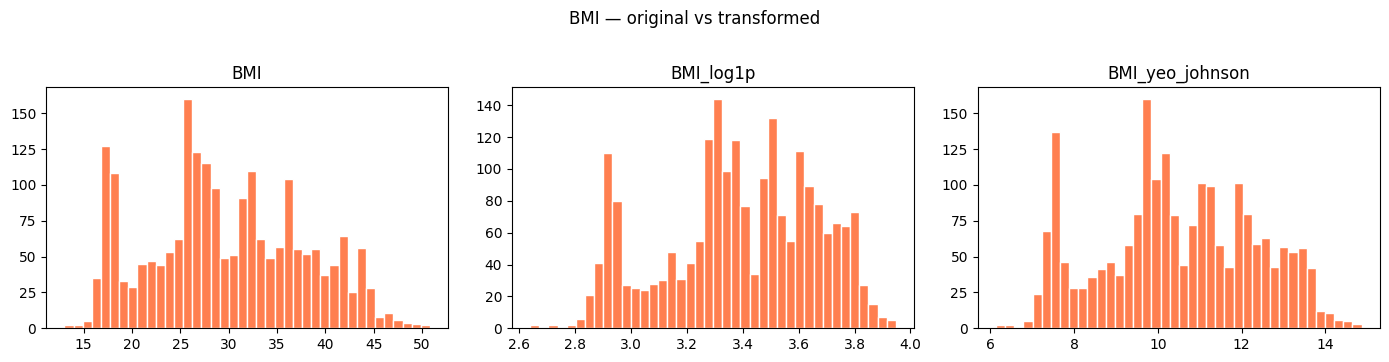

In [ ]:
def apply_log_transforms(
    df: pd.DataFrame,
    columns: list
) -> pd.DataFrame:
    """Apply log1p and square-root transforms. Clips negatives to 0 before transform."""
    out = df.copy()
    for col in columns:
        out[f'{col}_log1p'] = np.log1p(out[col].clip(lower=0))
        out[f'{col}_sqrt']  = np.sqrt(out[col].clip(lower=0))
    return out


def apply_power_transform(
    df: pd.DataFrame,
    columns: list,
    method: str = 'yeo-johnson'
) -> pd.DataFrame:
    """
    Apply sklearn PowerTransformer.

    Parameters
    ----------
    method : 'yeo-johnson' (handles zeros/negatives) or 'box-cox' (requires x > 0)
    """
    out = df.copy()
    pt  = PowerTransformer(method=method, standardize=False)
    transformed = pt.fit_transform(out[columns].fillna(out[columns].median()))
    suffix = method.replace('-', '_')
    for i, col in enumerate(columns):
        out[f'{col}_{suffix}'] = transformed[:, i]
    return out


# ── Apply ──────────────────────────────────────────────────────────────────────
# Only truly continuous measurements benefit from these transforms
transform_cols = ['Age', 'Weight', 'BMI', 'health_score', 'risk_score']

before = df.copy()
df = apply_log_transforms(df, transform_cols)
df = apply_power_transform(df, transform_cols, method='yeo-johnson')
show_new_columns(before, df)

# Compare BMI distributions before / after
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ['BMI', 'BMI_log1p', 'BMI_yeo_johnson']):
    ax.hist(df[col].dropna(), bins=40, edgecolor='white', color='coral')
    ax.set_title(col)
plt.suptitle('BMI — original vs transformed', y=1.02)
plt.tight_layout()
plt.show()

---
## 16. Feature Scaling

Bring numeric features onto a comparable scale — critical for distance-based and gradient-based models.

| Scaler | Output range | Sensitive to outliers? | Best for |
|--------|-------------|----------------------|---------|
| `StandardScaler` | mean=0, std=1 | Yes | Gaussian-ish features |
| `MinMaxScaler` | [0, 1] | Yes | Bounded features |
| `RobustScaler` | median-centred / IQR-scaled | **No** | Skewed / outlier-heavy |

In [ ]:
def apply_scaling(
    df: pd.DataFrame,
    columns: list,
    scaler_type: str = 'standard'
) -> pd.DataFrame:
    """
    Scale numeric columns and store results under new names with a suffix.

    Parameters
    ----------
    columns     : numeric columns to scale
    scaler_type : 'standard' | 'minmax' | 'robust'
    """
    scaler_registry = {
        'standard': (StandardScaler, 'std'),
        'minmax'  : (MinMaxScaler,   'mm'),
        'robust'  : (RobustScaler,   'rob'),
    }
    if scaler_type not in scaler_registry:
        raise ValueError(f'Unknown scaler: {scaler_type}. Choose from {list(scaler_registry)}')

    ScalerClass, suffix = scaler_registry[scaler_type]
    out    = df.copy()
    scaler = ScalerClass()
    X_sc   = scaler.fit_transform(out[columns].fillna(out[columns].median()))
    for i, col in enumerate(columns):
        out[f'{col}_{suffix}'] = X_sc[:, i]
    return out


# ── Apply all three scalers on core numeric & composite columns ────────────────
scale_cols = [
    'Age', 'Height', 'Weight', 'BMI',
    'health_score', 'risk_score', 'sedentary_score',
    'caloric_balance_proxy', 'activity_to_sedentary'
]

before = df.copy()
df = apply_scaling(df, scale_cols, scaler_type='standard')
df = apply_scaling(df, scale_cols, scaler_type='minmax')
df = apply_scaling(df, scale_cols, scaler_type='robust')
show_new_columns(before, df)

27 new column(s): ['Age_std', 'Height_std', 'Weight_std', 'BMI_std', 'health_score_std', 'risk_score_std', 'sedentary_score_std', 'caloric_balance_proxy_std', 'activity_to_sedentary_std', 'Age_mm', 'Height_mm', 'Weight_mm', 'BMI_mm', 'health_score_mm', 'risk_score_mm', 'sedentary_score_mm', 'caloric_balance_proxy_mm', 'activity_to_sedentary_mm', 'Age_rob', 'Height_rob', 'Weight_rob', 'BMI_rob', 'health_score_rob', 'risk_score_rob', 'sedentary_score_rob', 'caloric_balance_proxy_rob', 'activity_to_sedentary_rob']


,Age_std,Height_std,Weight_std,BMI_std,health_score_std,risk_score_std,sedentary_score_std,caloric_balance_proxy_std,activity_to_sedentary_std,Age_mm,Height_mm,Weight_mm,BMI_mm,health_score_mm,risk_score_mm,sedentary_score_mm,caloric_balance_proxy_mm,activity_to_sedentary_mm,Age_rob,Height_rob,Weight_rob,BMI_rob,health_score_rob,risk_score_rob,sedentary_score_rob,caloric_balance_proxy_rob,activity_to_sedentary_rob
0,-0.5221,-0.8756,-0.8626,-0.6634,-1.0694,-2.3241,-0.0730,0.2104,-0.9921,0.1489,0.3208,0.1866,0.3012,0.2857,0.1667,0.4000,0.5455,0.0000,-0.2937,-0.5814,-0.4528,-0.3706,-1.0000,-2.0000,0.0000,0.0000,-0.5000
1,-0.5221,-1.9476,-1.1681,-0.6819,2.6314,0.2918,-1.0740,2.1116,3.2961,0.1489,0.1321,0.1269,0.2972,1.0000,0.5000,0.2000,0.8182,1.0000,-0.2937,-1.3036,-0.6435,-0.3833,1.5000,0.0000,-0.5000,1.5000,2.5000
2,-0.2069,1.0540,-0.3661,-0.7410,0.4109,0.2918,-0.0730,0.2104,0.4373,0.1915,0.6604,0.2836,0.2847,0.5714,0.5000,0.4000,0.5455,0.3333,0.0367,0.7186,-0.1430,-0.4237,0.0000,0.0000,0.0000,0.0000,0.5000


---
## 17. Summary & Save

In [ ]:
original_cols   = list(df_raw.columns)
engineered_cols = [c for c in df.columns if c not in original_cols]

print(f'Shape after all engineering: {df.shape}')
print(f'  Original columns   : {len(original_cols)}')
print(f'  Engineered columns : {len(engineered_cols)}')
print()

# Group new columns by technique
groups = {
    'SMOTE recovery'   : [c for c in engineered_cols if '_int' in c or '_label' in c],
    'Domain features'  : ['BMI', 'BMI_category', 'weight_height_ratio', 'age_group',
                           'health_score', 'risk_score', 'sedentary_score',
                           'caloric_balance_proxy', 'activity_to_sedentary', 'hydration_per_meal'],
    'Binary encoding'  : [c for c in engineered_cols if c.endswith('_bin')],
    'Ordinal encoding' : [c for c in engineered_cols if c.endswith('_ordinal')],
    'One-Hot encoding' : [c for c in engineered_cols if any(
                            c.startswith(p) for p in ['Gender_', 'MTRANS_'])],
    'Freq encoding'    : [c for c in engineered_cols if c.endswith('_freq')],
    'Target encoding'  : [c for c in engineered_cols if c.endswith('_target_enc')],
    'Aggregation'      : [c for c in engineered_cols if any(
                            f'_{fn}' in c for fn in ['mean','std','min','max','dev_from'])],
    'Interactions'     : [c for c in engineered_cols if any(
                            op in c for op in ['_x_','_div_','_minus_','_plus_'])],
    'Polynomial'       : [c for c in engineered_cols if c.startswith('poly_')],
    'Binning'          : [c for c in engineered_cols if '_bin_' in c],
    'Transforms'       : [c for c in engineered_cols if any(
                            c.endswith(s) for s in ['_log1p','_sqrt','_yeo_johnson'])],
    'Scaling'          : [c for c in engineered_cols if any(
                            c.endswith(s) for s in ['_std','_mm','_rob'])],
}

for group, cols in groups.items():
    print(f'[{group}] ({len(cols)} cols): {cols[:6]}{" ..." if len(cols) > 6 else ""}')

Shape after all engineering: (2111, 228)
  Original columns   : 17
  Engineered columns : 211

[SMOTE recovery] (69 cols): ['FCVC_int', 'FCVC_label', 'NCP_int', 'NCP_label', 'CH2O_int', 'CH2O_label'] ...
[Domain features] (10 cols): ['BMI', 'BMI_category', 'weight_height_ratio', 'age_group', 'health_score', 'risk_score'] ...
[Binary encoding] (4 cols): ['family_history_with_overweight_bin', 'FAVC_bin', 'SMOKE_bin', 'SCC_bin']
[Ordinal encoding] (8 cols): ['CAEC_ordinal', 'CALC_ordinal', 'NObeyesdad_ordinal', 'FCVC_label_ordinal', 'NCP_label_ordinal', 'CH2O_label_ordinal'] ...
[One-Hot encoding] (49 cols): ['Gender_Male', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking', 'MTRANS_freq'] ...
[Freq encoding] (4 cols): ['MTRANS_freq', 'CAEC_freq', 'CALC_freq', 'Gender_freq']
[Target encoding] (9 cols): ['Gender_target_enc', 'MTRANS_target_enc', 'CAEC_target_enc', 'CALC_target_enc', 'FCVC_label_target_enc', 'CH2O_label_target_enc'] ...
[Aggregation] (83 col

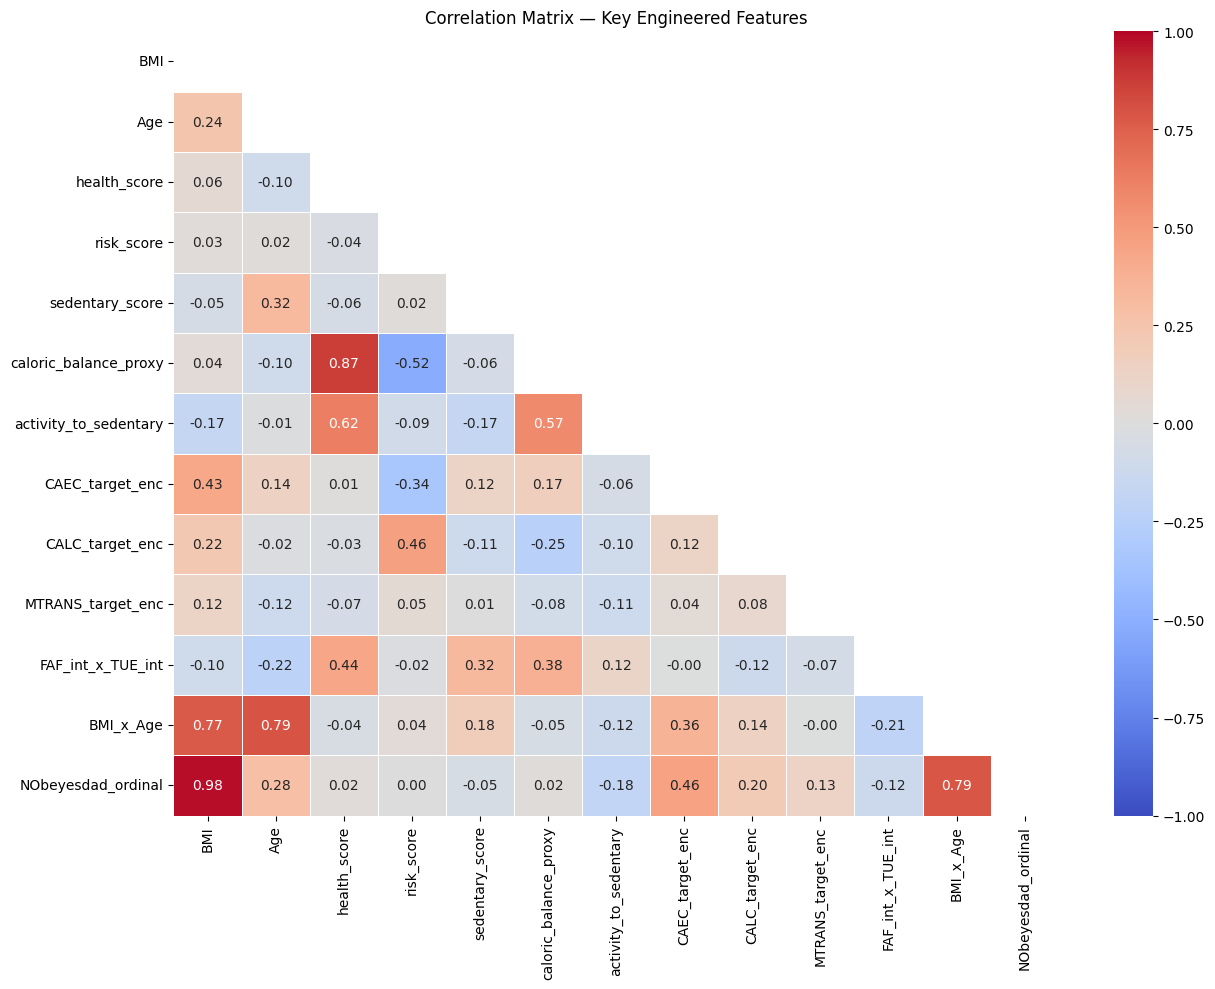

In [ ]:
# ── Correlation heatmap — key engineered features vs target ───────────────────
key_features = [
    'BMI', 'Age', 'health_score', 'risk_score',
    'sedentary_score', 'caloric_balance_proxy', 'activity_to_sedentary',
    'CAEC_target_enc', 'CALC_target_enc', 'MTRANS_target_enc',
    'FAF_int_x_TUE_int', 'BMI_x_Age',
    'NObeyesdad_ordinal'
]
key_features = [c for c in key_features if c in df.columns]

plt.figure(figsize=(13, 10))
corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Key Engineered Features')
plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_PATH = 'ObesityDataSet_feature_engineered.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved → {OUTPUT_PATH}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')